# PEMFC Polarization Curve — Comparison with Vetter & Schumacher (2019)

This notebook reproduces the **base-case** simulation from

> R. Vetter, J. O. Schumacher, *Comput. Phys. Commun.* **234**, 223–234 (2019)

using the `marapendi` transient cell model.  Cell parameters and operating conditions
match Tables 3–5 of that paper (Nafion membrane and ionomer, Toray TGP-H-060 GDLs, 70 °C, 1.5 bar,
90 % RH at both inlets).  Section 5 compares the key figures from Table 6 of the paper
with those computed here.

In [9]:
import numpy as np
import cantera as ct
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

import marapendi.dynamic as mrpd

## 1 — Cell assembly

All parameters follow Vetter & Schumacher (2019) Tables 3 and 4.

In [10]:
# ── Kinetics ──────────────────────────────────────────────────────────────
# ORR: Neyerlin et al. (2006); Eq. 18 of Vetter & Schumacher (2019).
# activation_energy in J/kmol (Cantera convention): 67 kJ/mol = 67e6 J/kmol.
orr_kinetics = mrpd.ElectrochemicalReaction(
    reference_exchange_current_density=2.45e-4,   # A/m2_Pt
    activation_energy=67e6,                        # J/kmol = 67 kJ/mol
    reaction_order=0.54,
    reference_activity=1.e5,                       # Pa (1 atm reference)
    reference_temperature=353.15,                  # K  (80 C)
    number_of_electrons=1,
    charge_transfer_coeff=1,
)


# ── GDLs — Toray TGP-H-060 (Table 4) ─────────────────────────────────────
gdl_an = mrpd.PorousLayer(
    thickness=160e-6, eps_p=0.76, bulk_density=440.,
    bulk_specific_heat_capacity=710., bulk_thermal_conductivity=1.6,
    K_abs=6.15e-12, theta_contact=130., tort=1.6**2
)
gdl_ca = mrpd.PorousLayer(
    thickness=160e-6, eps_p=0.76, bulk_density=440.,
    bulk_specific_heat_capacity=710., bulk_thermal_conductivity=1.6,
    K_abs=6.15e-12, theta_contact=130., tort=1.6**2
)

# ── Nafion NR-211 ionomer (Section 3.3) ──────────────────────────────────
# EW = 1100 g/mol, rho_dry = 2000 kg/m3.
# Sorption isotherm: Springer et al. (1991) Eq. 24.
# Desorption coefficient a_d = 1.42e-2 cm/s; absorption a_a = 3.53e-3 cm/s
# (Ge et al. 2005, cited as Eq. 25 in Vetter & Schumacher).
nafion = mrpd.PFSAIonomer(
    rho_dry_ion=1.97e3, EW_ion=1020,
    # Vetter & Schumacher (2019) Eq. 22, fit to Mittelsteadt & Staser (2011)
    darken_num_ion=np.array([0., 67.74, -32.03, 3.842]),          # ascending degree: c0 + c1*lmbd + c2*lmbd^2 + c3*lmbd^3
    darken_den_ion=np.array([103.37, -33.013, -2.115, 1.0]),       # ascending degree
    sorption_coeffs_ion=np.array([0.043, 17.81, -39.85, 36.0]),
    lmbd_liq_ref_ion=22,
    D_lmbd_ref_ion=1.0e-10,        # 10^-6 cm^2/s = 10^-10 m^2/s (Vetter Eq. 22)
    k_des_ref_ion=1.42e-4,   # a_d = 1.42e-2 cm/s -> 1.42e-4 m/s
    E_act_ion=20e6,           # J/kmol = 20 kJ/mol
    E_act_cond_ion=15e6,
    sigma_ref_ion=116.,
    f_v_perc_ion=0.06, n_sigma_ion=1.5,
    T_ref_sigma_ion=353.15, T_ref_D_ion=353.15, T_ref_des_ion=353.15,
)


# ── Catalyst layers ────────────────────────────────────────────────────────
# Cathode: Pt loading 3x anode -> a_ca = 3e11 cm2_Pt/m3  (Table 4)
ca_cl = mrpd.PtCCatalystLayer(
    thickness=10e-6,
    bulk_density=1000., bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=0.27,
    L_Pt=0.4e-2, wt_Pt=0.416, ic_ratio=1.04, ecsa=75e3, 
    tort=1.6**2, ionomer=nafion,
    r_C=1e-10, K_abs=1e-13, theta_contact=95,
    reaction=orr_kinetics
)
# Anode: 1/3 Pt loading -> a_an = 1e11 cm2_Pt/m3
an_cl = mrpd.PtCCatalystLayer(
    thickness=10e-6,
    bulk_density=1000., bulk_specific_heat_capacity=710.,
    bulk_thermal_conductivity=0.27,
    L_Pt=0.4e-2 / 3, wt_Pt=0.192, ic_ratio=1.07, ecsa=75e3,
    tort=1.6**2, ionomer=nafion,
    r_C=1e-10, K_abs=1e-13, theta_contact=95
)

# ── Cell assembly ──────────────────────────────────────────────────────────
cell = mrpd.Cell(
    area=25e-4,
    electrical_resistance=80e-6/1250. + 5e-6/350.,
    thermal_resistance=0,
    ca=mrpd.CellSide(
        cl=ca_cl, gdl=gdl_ca,
        ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
        has_mpl=False,
    ),
    an=mrpd.CellSide(
        cl=an_cl, gdl=gdl_an,
        ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
        has_mpl=False,
    ),
    memb=mrpd.PFSAMembrane(
        thickness=25e-6,              # Nafion NR-211
        bulk_thermal_conductivity=0.3,
        ionomer=nafion,
    ),
)
print(cell.eps_ion, cell.eps_p)

[[0.        ]
 [0.        ]
 [0.30476593]
 [1.        ]
 [0.2964467 ]
 [0.        ]
 [0.        ]] [[1.        ]
 [0.76      ]
 [0.40126877]
 [0.6       ]
 [0.39693684]
 [0.76      ]
 [1.        ]]


## 2 — Model setup and initial conditions

In [11]:
# Operating conditions — Table 5 of Vetter & Schumacher (2019)
T_OP = 343.15   # K  (70 °C)
P_OP = 1.5e5    # Pa (1.5 bar)
RH   = 0.9      # 90 % RH at both inlets
S_C  = 0.12     # cathode GDL/channel liquid saturation

base = mrpd.CellBaseModel(
    transient_transport_model=mrpd.TransientCellModel(cell=cell, current_density=0.),
    memb_model=mrpd.PFSAModel(),
    cl_model=mrpd.PtCCatalystLayerModel(),
    gas_diffusion_model=mrpd.PorousGasResistanceModel(),
    darcy_transport_model=mrpd.DarcyTransportModel(),
    voltage_model=mrpd.VoltageModel(),
)
model = base.transient_transport_model

# ── Inlet conditions — differential-cell approximation ───────────────────
# Flow rates scale with current density at fixed stoichiometry S=1000.
# A 1 A/m² floor prevents zero-flow at t=0; mole fractions (and hence
# channel concentrations = x_k * P / RT) are independent of flow magnitude.
STOICH = 1000.

def _i_ref(t):
    i = model.current_density(t) if callable(model.current_density) else float(model.current_density)
    return max(float(i), 1.)   # 1 A/m² floor

ca_cond = mrpd.InletAirConditions(
    temperature          = T_OP,
    backpressure         = P_OP,
    rh_ref_pressure      = P_OP,
    o2_molar_flow_rate   = lambda t: STOICH * _i_ref(t) * cell.area / (4 * ct.faraday),
    o2_dry_mole_fraction = 0.21,                  # air
    inlet_rh             = RH,
)
an_cond = mrpd.InletHydrogenConditions(
    temperature          = T_OP,
    backpressure         = P_OP,
    rh_ref_pressure      = P_OP,
    h2_molar_flow_rate   = lambda t: 2 * STOICH * _i_ref(t) * cell.area / (4 * ct.faraday),
    inlet_rh             = RH,
)
conditions = mrpd.CellConditions(current_density=0., ca=ca_cond, an=an_cond)

y0 = model.initial_state_from_conditions(conditions.at(0.), s_ca=S_C)

[31.998 28.014  2.016 18.015]


In [29]:
x0 = base.postprocess(y0, i_density=0)
x0.x_g_k[:,3]

array([[0.18720588],
       [0.18720588],
       [0.18720588],
       [0.        ],
       [0.18720588],
       [0.18720588],
       [0.18720588]])

## 3 — Galvanostatic polarization curve sweep

Each current-density step is integrated for `T_STEP` seconds.  The integration
time must exceed the liquid-saturation timescale (~14 s in the GDL at low *s*,
longer at higher *s*) so that *s* and hence the ionomer water content reach
quasi-steady state before the cell voltage is recorded.

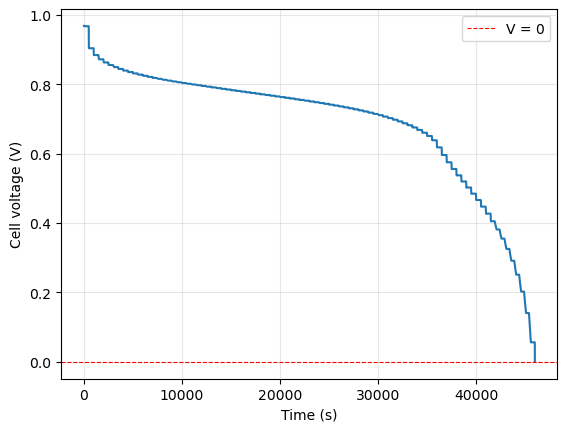

In [12]:
CURRENT_DENSITIES = np.linspace(0, 20000, 101)   # A/m2  (0 to 2 A/cm2)
T_STEP = 500.0   # s per step
T_AVG  = 30.0    # s at end of each step to average for quasi-steady voltage

tx = sum([[k * T_STEP, (k+1) * T_STEP - 10] for k in range(len(CURRENT_DENSITIES))], start=[])
ix = sum([[CURRENT_DENSITIES[k], CURRENT_DENSITIES[k]] for k in range(len(CURRENT_DENSITIES))], start=[])

i_profile = lambda t: np.interp(t, tx, ix)
conditions.current_density = i_profile
model.current_density = i_profile

def _voltage_zero_crossing(t, y):
    """Terminal event: fires when V_cell passes through zero (going negative)."""
    st = base.postprocess(y[:, np.newaxis], i_density=float(model.current_density(t)))
    return float(st.V_cell.item())

_voltage_zero_crossing.terminal  = True
_voltage_zero_crossing.direction = -1   # only trigger on downward crossing

sol_full   = base.solve(y0, t_span=(tx[0], tx[-1]), max_step=100.,
                        events=_voltage_zero_crossing)
state_full = base.postprocess(sol_full.y, i_density=model.current_density(sol_full.t))

# Time-average voltage per step; NaN for steps the integrator never reached.
V_arr = np.full(len(CURRENT_DENSITIES), np.nan)
for k in range(len(CURRENT_DENSITIES)):
    if sol_full.t[-1] < k * T_STEP:
        break   # all remaining steps unreached
    t_hi  = min((k + 1) * T_STEP, sol_full.t[-1])
    j_hi  = np.searchsorted(sol_full.t, t_hi, side='right')
    j_lo  = np.searchsorted(sol_full.t, t_hi - T_AVG, side='left')
    j_lo  = min(j_lo, j_hi - 1)
    V_arr[k] = state_full.V_cell[j_lo:j_hi].mean()

plt.plot(sol_full.t, state_full.V_cell)
plt.axhline(0, color='r', lw=0.8, ls='--', label='V = 0')
plt.xlabel('Time (s)')
plt.ylabel('Cell voltage (V)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4 — Polarization and power-density curves

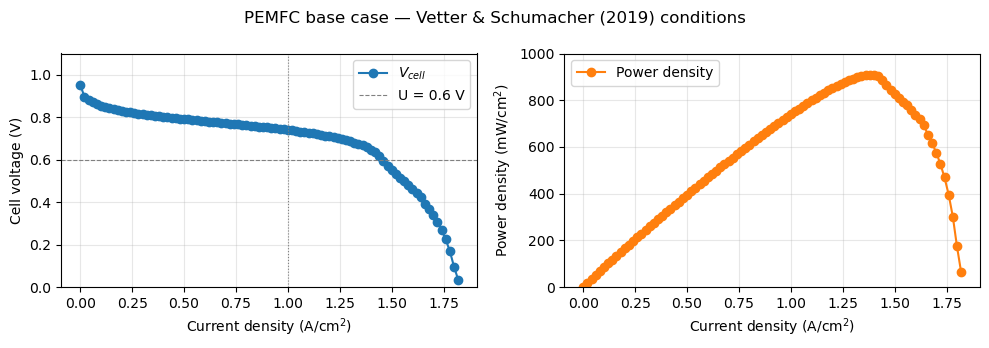

In [13]:
i_Acm2 = CURRENT_DENSITIES / 1e4
P_arr  = i_Acm2 * V_arr   # W/cm2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle("PEMFC base case — Vetter & Schumacher (2019) conditions", fontsize=12)

ax1.plot(i_Acm2, V_arr, 'C0-o', label='$V_{cell}$')
ax1.set_xlabel('Current density (A/cm$^2$)')
ax1.set_ylabel('Cell voltage (V)')
ax1.set_ylim(0, 1.1)
ax1.axhline(0.6, color='grey', lw=0.8, ls='--', label='U = 0.6 V')
ax1.axvline(1.0, color='grey', lw=0.8, ls=':')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(i_Acm2, P_arr * 1e3, 'C1-o', label='Power density')
ax2.set_xlabel('Current density (A/cm$^2$)')
ax2.set_ylabel('Power density (mW/cm$^2$)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0,1000)
ax2.legend()

fig.tight_layout()
plt.show()

## 5 — Comparison with Table 6 of Vetter & Schumacher (2019)

Derived quantities follow the definitions in the paper (Eqs. 29–31).  The operating
point at **U = 0.6 V** is obtained by linear interpolation of the polarization curve.

In [ ]:
# ── Interpolation helpers ─────────────────────────────────────────────────
valid  = V_arr > 0.05
i_v    = i_Acm2[valid]
V_v    = V_arr[valid]

# V is monotonically decreasing so reverse for interp1d
V_to_I = interp1d(V_v[::-1], i_v[::-1], kind='linear',
                   bounds_error=False, fill_value='extrapolate')
I_to_V = interp1d(i_v, V_v, kind='linear',
                   bounds_error=False, fill_value='extrapolate')

i_at_06  = float(V_to_I(0.6))          # A/cm2
V_at_1   = float(I_to_V(1.0))          # V at 1 A/cm2
# nanargmin: np.argmin returns the first NaN index when V_arr has NaN entries,
# which points to an unreached step and lands j06 at sol_full.t[-1].
idx_06   = int(np.nanargmin(np.abs(V_arr - 0.6)))

# Extract state snapshot at the end of the step closest to 0.6 V from the
# combined solve (sol_full/state_full are not overwritten by the step loop).
t_hi06 = min((idx_06 + 1) * T_STEP, sol_full.t[-1])
j06    = np.searchsorted(sol_full.t, t_hi06, side='right') - 1
st06   = base.postprocess(sol_full.y[:, j06:j06+1],
                           i_density=float(CURRENT_DENSITIES[idx_06]))

# ── Peak power and limit current density ─────────────────────────────────
peak_power = float(np.nanmax(i_Acm2 * V_arr))   # W/cm2 — nanmax skips unreached steps
i_lim      = float(i_v[-1]) if len(i_v) >= 1 else float('nan')  # last point before V→0

# ── State quantities at the 0.6 V operating point ─────────────────────────
c = cell

# Peak and average temperature over the MEA (GDL to GDL, Eq. 30)
mea_layers = [c.an.gdl, c.an.cl, c.memb, c.ca.cl, c.ca.gdl]
mea_ix     = [l.ix for l in mea_layers]
mea_L      = np.array([l.thickness for l in mea_layers])
T_C        = st06.T[:, 0] - 273.15    # convert to Celsius
T_peak     = float(np.max(T_C[mea_ix]))
T_avg      = float(np.dot(T_C[mea_ix], mea_L) / mea_L.sum())

# Minimum and volume-averaged lambda over CCM (ACL + PEM + CCL, Eq. 31)
ccm_ix   = [c.an.cl.ix, c.memb.ix, c.ca.cl.ix]
ccm_eps  = c.eps_ion[ccm_ix, 0]
ccm_L    = c.thickness[ccm_ix, 0]
lmbd06   = st06.lmbd[:, 0]
lmbd_min = float(np.min(lmbd06[ccm_ix]))
lmbd_avg = float(np.dot(ccm_eps * lmbd06[ccm_ix], ccm_L) / np.dot(ccm_eps, ccm_L))

# Water flux through PEM (positive = anode -> cathode)
# J[memb.ix, i_lmbd] in kmol/(m2.s); convert to umol/(cm2.s): x 1e9 / 1e4
J_PEM = float(st06.J[c.memb.ix, model.i_lmbd, 0]) * 1e5

# Membrane ohmic resistance R_PEM = integral_PEM (1/sigma_p) dx  (Eq. 29), in mOhm.cm2
def _sigma(ix):
    return base.memb_model.charge_conductivity(
        float(st06.f_v[ix, 0]), float(st06.T[ix, 0]), 'proton', c.memb)
sigma_left   = _sigma(c.an.cl.ix)
sigma_center = _sigma(c.memb.ix)
sigma_right  = _sigma(c.ca.cl.ix)
R_PEM = (c.memb.thickness / 6
         * (1/sigma_left + 4/sigma_center + 1/sigma_right)
         * 1e4 * 1e3)  # Ohm.m2 -> mOhm.cm2

# ── Print comparison table ────────────────────────────────────────────────
rows = [
    ('Peak power density          (W/cm2)',    peak_power,  0.901),
    ('Limit current density        (A/cm2)',   i_lim,       1.960),
    ('Cell voltage at I=1 A/cm2       (V)',    V_at_1,      0.720),
    ('Current density at U=0.6 V  (A/cm2)',   i_at_06,     1.499),
    ('Peak temperature at 0.6 V      (C)',     T_peak,      70.90),
    ('Average temperature at 0.6 V   (C)',     T_avg,       70.36),
    ('Min. water content at 0.6 V    (-)',      lmbd_min,    3.72 ),
    ('Avg. water content at 0.6 V    (-)',      lmbd_avg,    6.68 ),
    ('Water flux through PEM (umol/cm2s)',      J_PEM,       3.05 ),
    ('Membrane resistance         (mOhm.cm2)', R_PEM,      83.9  ),
]

hdr = f"{'Quantity':<44} {'This model':>12} {'Vetter 2019':>12}"
print(hdr)
print('-' * len(hdr))
for name, ours, ref in rows:
    print(f"{name:<44} {ours:>12.3f} {ref:>12.3f}")

## 6 — Internal state vs. current density

Key quantities extracted from the quasi-steady state at the end of each
galvanostatic step, plotted against current density.

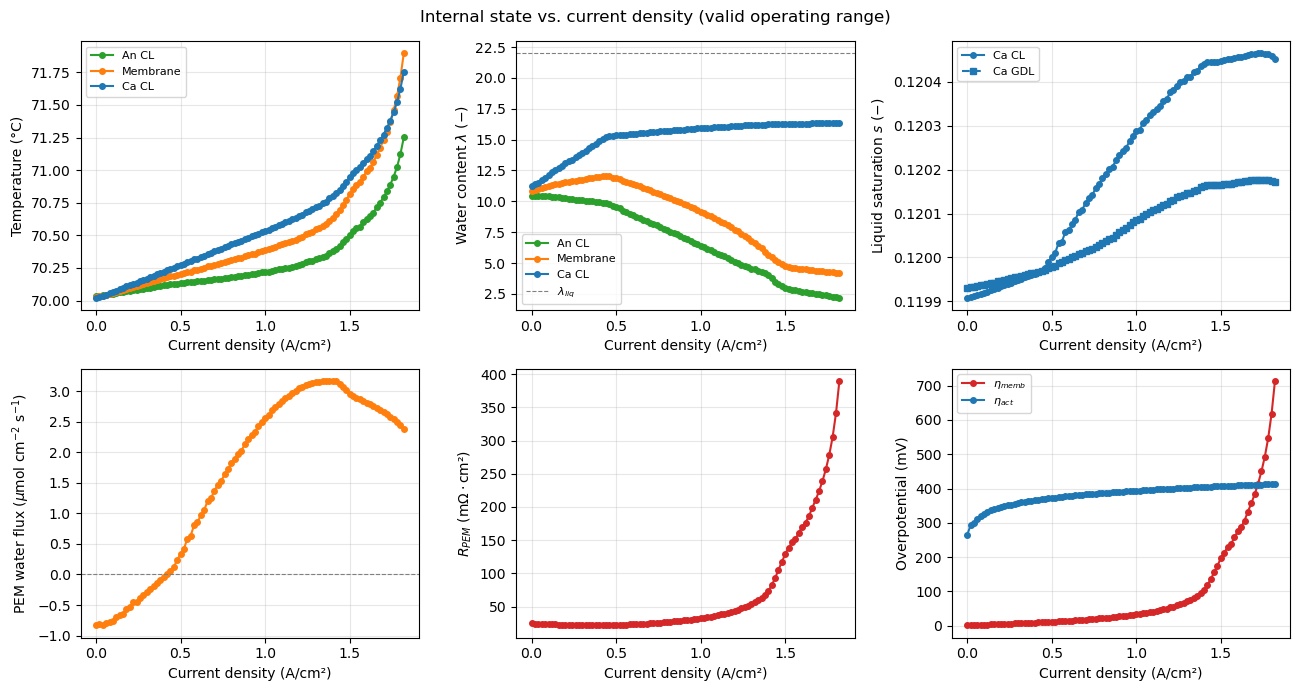

In [15]:
c = cell
valid = V_arr > 0
valid_k = np.where(valid)[0]
i_v2 = i_Acm2[valid_k]

# Last time index within each galvanostatic step
j_end = np.array([
    np.searchsorted(sol_full.t, min((k + 1) * T_STEP, sol_full.t[-1]), side='right') - 1
    for k in range(len(CURRENT_DENSITIES))
])
j_v = j_end[valid_k]

# ── Per-step diagnostics extracted directly from state_full ──────────────
T_an  = state_full.T[c.an.cl.ix, j_v] - 273.15
T_mb  = state_full.T[c.memb.ix,  j_v] - 273.15
T_ca  = state_full.T[c.ca.cl.ix, j_v] - 273.15

lmbd_an = state_full.lmbd[c.an.cl.ix, j_v]
lmbd_mb = state_full.lmbd[c.memb.ix,  j_v]
lmbd_ca = state_full.lmbd[c.ca.cl.ix, j_v]

s_ca_cl  = state_full.s[c.ca.cl.ix,  j_v]
s_ca_gdl = state_full.s[c.ca.gdl.ix, j_v]

J_PEM_arr = state_full.J[c.memb.ix, model.i_lmbd, j_v] * 1e5

def _R_PEM_at(j):
    def _sig(ix):
        return base.memb_model.charge_conductivity(
            float(state_full.f_v[ix, j]), float(state_full.T[ix, j]), 'proton', c.memb)
    return (c.memb.thickness / 6
            * (1/_sig(c.an.cl.ix) + 4/_sig(c.memb.ix) + 1/_sig(c.ca.cl.ix))
            * 1e4 * 1e3)

R_PEM_arr    = np.array([_R_PEM_at(j) for j in j_v])
eta_memb_arr = state_full.eta_memb[j_v] * 1e3   # mV
eta_act_arr  = state_full.eta_act[j_v]  * 1e3   # mV

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle("Internal state vs. current density (valid operating range)", fontsize=12)

kw = dict(ms=4)

ax = axes[0, 0]
ax.plot(i_v2, T_an, 'C2-o', **kw, label='An CL')
ax.plot(i_v2, T_mb, 'C1-o', **kw, label='Membrane')
ax.plot(i_v2, T_ca, 'C0-o', **kw, label='Ca CL')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(i_v2, lmbd_an, 'C2-o', **kw, label='An CL')
ax.plot(i_v2, lmbd_mb, 'C1-o', **kw, label='Membrane')
ax.plot(i_v2, lmbd_ca, 'C0-o', **kw, label='Ca CL')
ax.axhline(22, color='grey', lw=0.8, ls='--', label=r'$\lambda_{liq}$')
ax.set_ylabel(r'Water content $\lambda$ (−)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot(i_v2, s_ca_cl,  'C0-o',  **kw, label='Ca CL')
ax.plot(i_v2, s_ca_gdl, 'C0--s', **kw, label='Ca GDL')
ax.set_ylabel('Liquid saturation $s$ (−)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(i_v2, J_PEM_arr, 'C1-o', **kw)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel(r'PEM water flux ($\mu$mol cm$^{-2}$ s$^{-1}$)')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(i_v2, R_PEM_arr, 'C3-o', **kw)
ax.set_ylabel(r'$R_{PEM}$ (m$\Omega\cdot$cm²)')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(i_v2, eta_memb_arr, 'C3-o', **kw, label=r'$\eta_{memb}$')
ax.plot(i_v2, eta_act_arr,  'C0-o', **kw, label=r'$\eta_{act}$')
ax.set_ylabel('Overpotential (mV)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Current density (A/cm²)')

fig.tight_layout()
plt.show()

## 7 — Capillary pressure–saturation: Vetter Eq. 27 vs. Van Genuchten model

Vetter & Schumacher (2019) use an empirical two-exponential fit for Toray
TGP-H-060 (Eq. 27, from Nguyen et al. 2008 [62]), while our model uses the
Van Genuchten (VGM) expression.

**Sign conventions differ:**  
- Vetter: p_c = p_liquid − p_gas → negative in the hydrophobic regime  
- VGM (our model): capillary pressure as magnitude, always ≥ 0  

The liquid transport is driven by ∂p_c/∂s (right panel), which is comparable
between the two models in the operating range, though Vetter's fit has a
steeper gradient at low saturations.

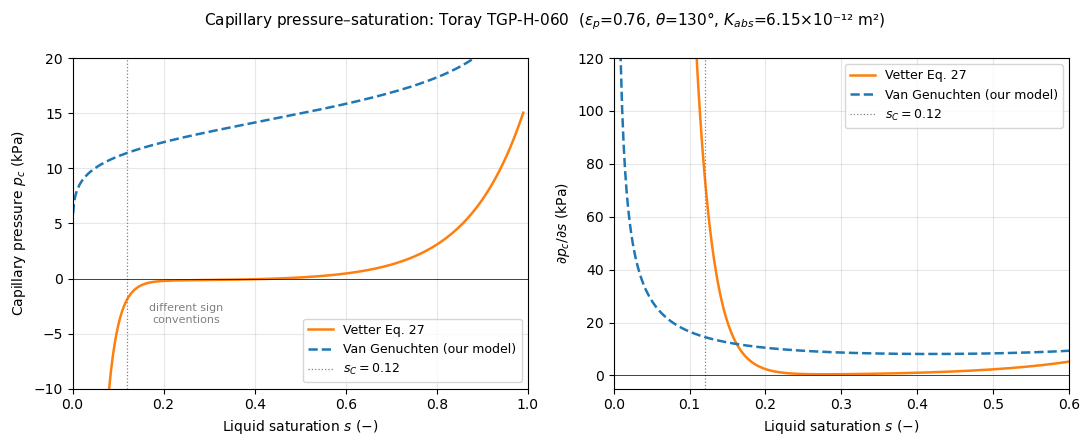

At s = 0.12:
  Vetter Eq. 27  : p_c = -1875 Pa,  dp_c/ds = 75165 Pa
  Van Genuchten  : p_c = 11401 Pa,  dp_c/ds = 14544 Pa


/var/folders/q2/mryrbb1x7yz_7_1dzt__d5n8w_l3v1/T/ipykernel_78298/2042635345.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  Van Genuchten  : p_c = {float(base.darcy_transport_model.capillary_pressure_from_saturation(np.array([0.12]), p_b_v, m_v, n_v)):.0f} Pa,  dp_c/ds = {float(np.gradient(pc_vgm, s_arr)[np.argmin(np.abs(s_arr - 0.12))]):.0f} Pa")


In [16]:
s_arr = np.linspace(1e-3, 0.99, 500)

# ── Vetter & Schumacher (2019) Eq. 27 — Toray TGP-H-060 ──────────────────
# Empirical two-exponential fit (Nguyen et al. 2008).
# Convention: p_c = p_liquid - p_gas; negative for hydrophobic at low s.
def p_c_vetter(s):
    x = s - 0.496
    return -0.00011 * np.exp(-44.02 * x) + 278.3 * np.exp(8.103 * x) - 191.8

pc_v = p_c_vetter(s_arr)

# ── Van Genuchten model (our GDL) ─────────────────────────────────────────
# p_c always >= 0; convention: pressure difference needed to enter pores.
p_b_v = float(cell.p_b[cell.ca.gdl.ix, 0])
m_v   = float(cell.van_genuchten_m[cell.ca.gdl.ix, 0])
n_v   = float(cell.van_genuchten_n[cell.ca.gdl.ix, 0])

pc_vgm = base.darcy_transport_model.capillary_pressure_from_saturation(
    s_arr, p_b_v, m_v, n_v
)

# Numerical derivatives
dpc_v   = np.gradient(pc_v,   s_arr)
dpc_vgm = np.gradient(pc_vgm, s_arr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    "Capillary pressure–saturation: Toray TGP-H-060  "
    r"($\varepsilon_p$=0.76, $\theta$=130°, $K_{abs}$=6.15×10⁻¹² m²)",
    fontsize=11
)

# ── Left: p_c(s) ──────────────────────────────────────────────────────────
ax1.plot(s_arr, pc_v   / 1e3, 'C1-',  lw=1.8, label='Vetter Eq. 27')
ax1.plot(s_arr, pc_vgm / 1e3, 'C0--', lw=1.8, label='Van Genuchten (our model)')
ax1.axvline(0.12, color='grey', lw=0.9, ls=':', label='$s_C = 0.12$')
ax1.axhline(0,    color='k',    lw=0.5)
ax1.set_xlim(0, 1)
ax1.set_ylim(-10, 20)
ax1.set_xlabel('Liquid saturation $s$ (−)')
ax1.set_ylabel('Capillary pressure $p_c$ (kPa)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.annotate(
    'different sign\nconventions', xy=(0.25, -4), fontsize=8,
    color='grey', ha='center'
)

# ── Right: dp_c/ds(s) — the Darcy transport driver ────────────────────────
ax2.plot(s_arr, dpc_v   / 1e3, 'C1-',  lw=1.8, label='Vetter Eq. 27')
ax2.plot(s_arr, dpc_vgm / 1e3, 'C0--', lw=1.8, label='Van Genuchten (our model)')
ax2.axvline(0.12, color='grey', lw=0.9, ls=':', label='$s_C = 0.12$')
ax2.axhline(0,    color='k',    lw=0.5)
ax2.set_xlim(0, 0.6)
ax2.set_ylim(-5, 120)
ax2.set_xlabel('Liquid saturation $s$ (−)')
ax2.set_ylabel(r'$\partial p_c / \partial s$ (kPa)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Summary at s = 0.12
print(f"At s = 0.12:")
print(f"  Vetter Eq. 27  : p_c = {p_c_vetter(0.12):.0f} Pa,  dp_c/ds = {float(np.gradient(pc_v, s_arr)[np.argmin(np.abs(s_arr - 0.12))]):.0f} Pa")
print(f"  Van Genuchten  : p_c = {float(base.darcy_transport_model.capillary_pressure_from_saturation(np.array([0.12]), p_b_v, m_v, n_v)):.0f} Pa,  dp_c/ds = {float(np.gradient(pc_vgm, s_arr)[np.argmin(np.abs(s_arr - 0.12))]):.0f} Pa")
